In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('data/jfk_weather_cleaned.csv')

In [8]:
df.shape

(75083, 11)

In [9]:
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              75083 non-null  object 
 1   VISIBILITY        75083 non-null  float64
 2   DRYBULBTEMPF      75083 non-null  int64  
 3   WETBULBTEMPF      75083 non-null  int64  
 4   DewPointTempF     75083 non-null  int64  
 5   RelativeHumidity  75083 non-null  int64  
 6   WindSpeed         75083 non-null  int64  
 7   WindDirection     75083 non-null  int64  
 8   StationPressure   75083 non-null  float64
 9   SeaLevelPressure  75083 non-null  float64
dtypes: float64(3), int64(6), object(1)
memory usage: 5.7+ MB


In [10]:
df.describe()

,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
count,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000
mean,9.211896,55.355527,49.327544,42.424024,64.812075,11.253240,196.550751,30.005579,30.026049,0.005478
std,2.202311,17.394334,16.182867,19.577957,19.898962,6.101048,107.692804,0.235172,0.234069,0.036161
min,0.000000,1.000000,-1.000000,-19.000000,8.000000,0.000000,0.000000,28.520000,28.540000,0.000000
25%,10.000000,42.000000,36.000000,27.000000,49.000000,7.000000,110.000000,29.860000,29.880000,0.000000
50%,10.000000,56.000000,50.000000,44.000000,66.000000,10.000000,200.000000,30.000000,30.020000,0.000000
75%,10.000000,70.000000,64.000000,59.000000,82.000000,15.000000,290.000000,30.150000,30.170000,0.000000
max,14.000000,102.000000,85.000000,84.000000,100.000000,53.000000,360.000000,30.830000,30.850000,2.410000


In [11]:
df.isna().sum()

DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
StationPressure     0
SeaLevelPressure    0
Precip              0
dtype: int64

In [23]:
df.duplicated().sum()

0

In [31]:
df['DATE'] = pd.to_datetime(df['DATE'],format='%Y-%m-%d %H:%M:%S')

In [22]:
df['DATE']

0        2010-01-01 00:51:00
1        2010-01-01 01:51:00
2        2010-01-01 02:51:00
3        2010-01-01 03:51:00
4        2010-01-01 04:51:00
                ...         
75078    2018-07-27 18:51:00
75079    2018-07-27 19:51:00
75080    2018-07-27 20:51:00
75081    2018-07-27 21:51:00
75082    2018-07-27 22:51:00
Name: DATE, Length: 75083, dtype: object

In [17]:
#define numerical and categorical columns
#drop id columns

columns = [column for column in df.columns if column != 'VISIBILITY']

numerical_columns = [feature for feature in df.columns if df[feature].dtype != 'object']
categorical_columns = [feature for feature in df.columns if df[feature].dtype == 'object']
# DATE is also a numeric feature as all the values are unique in it so its not categorial


In [21]:
print("Numeric columns:", numerical_columns)
print("Categorical columns:", categorical_columns)


Numeric columns: ['VISIBILITY', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure', 'SeaLevelPressure']
Categorical columns: ['DATE']


In [32]:
#univariate analysis

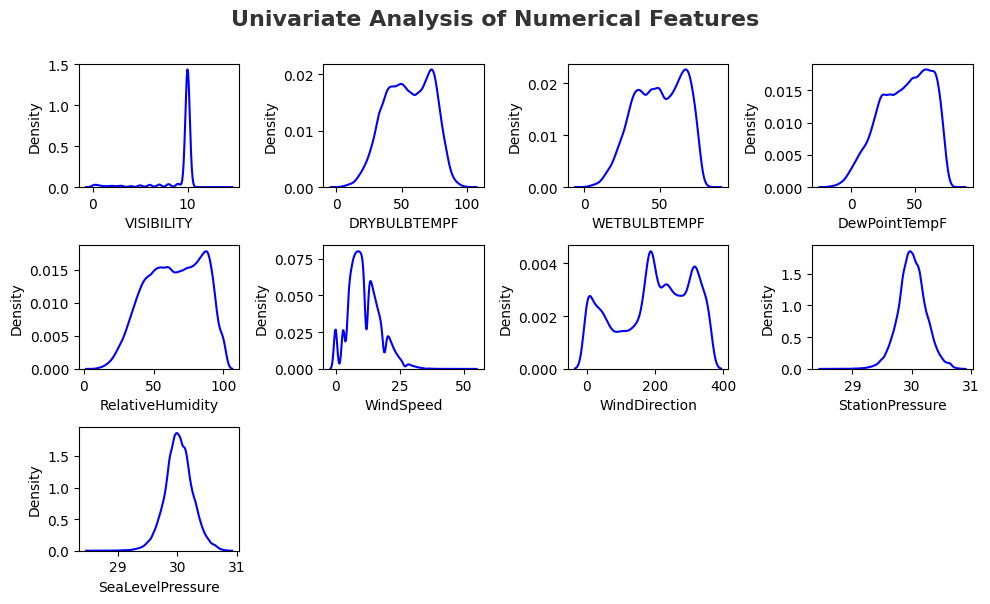

In [18]:
plt.figure(figsize=(10,6))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=16,fontweight='bold',alpha=0.8,y=1)
for i in range(0,len(numerical_columns)):
    plt.subplot(3,4,i+1)
    sns.kdeplot(x=df[numerical_columns[i]],color='blue')
    plt.xlabel(numerical_columns[i])
    plt.tight_layout()
#s#save plot
#plt.savefig('./images/univariate_numerical.png)

In [38]:
# We can observe that windspeed have the most skewness. winddirection follow after

In [12]:
#Multivariate Analaysis

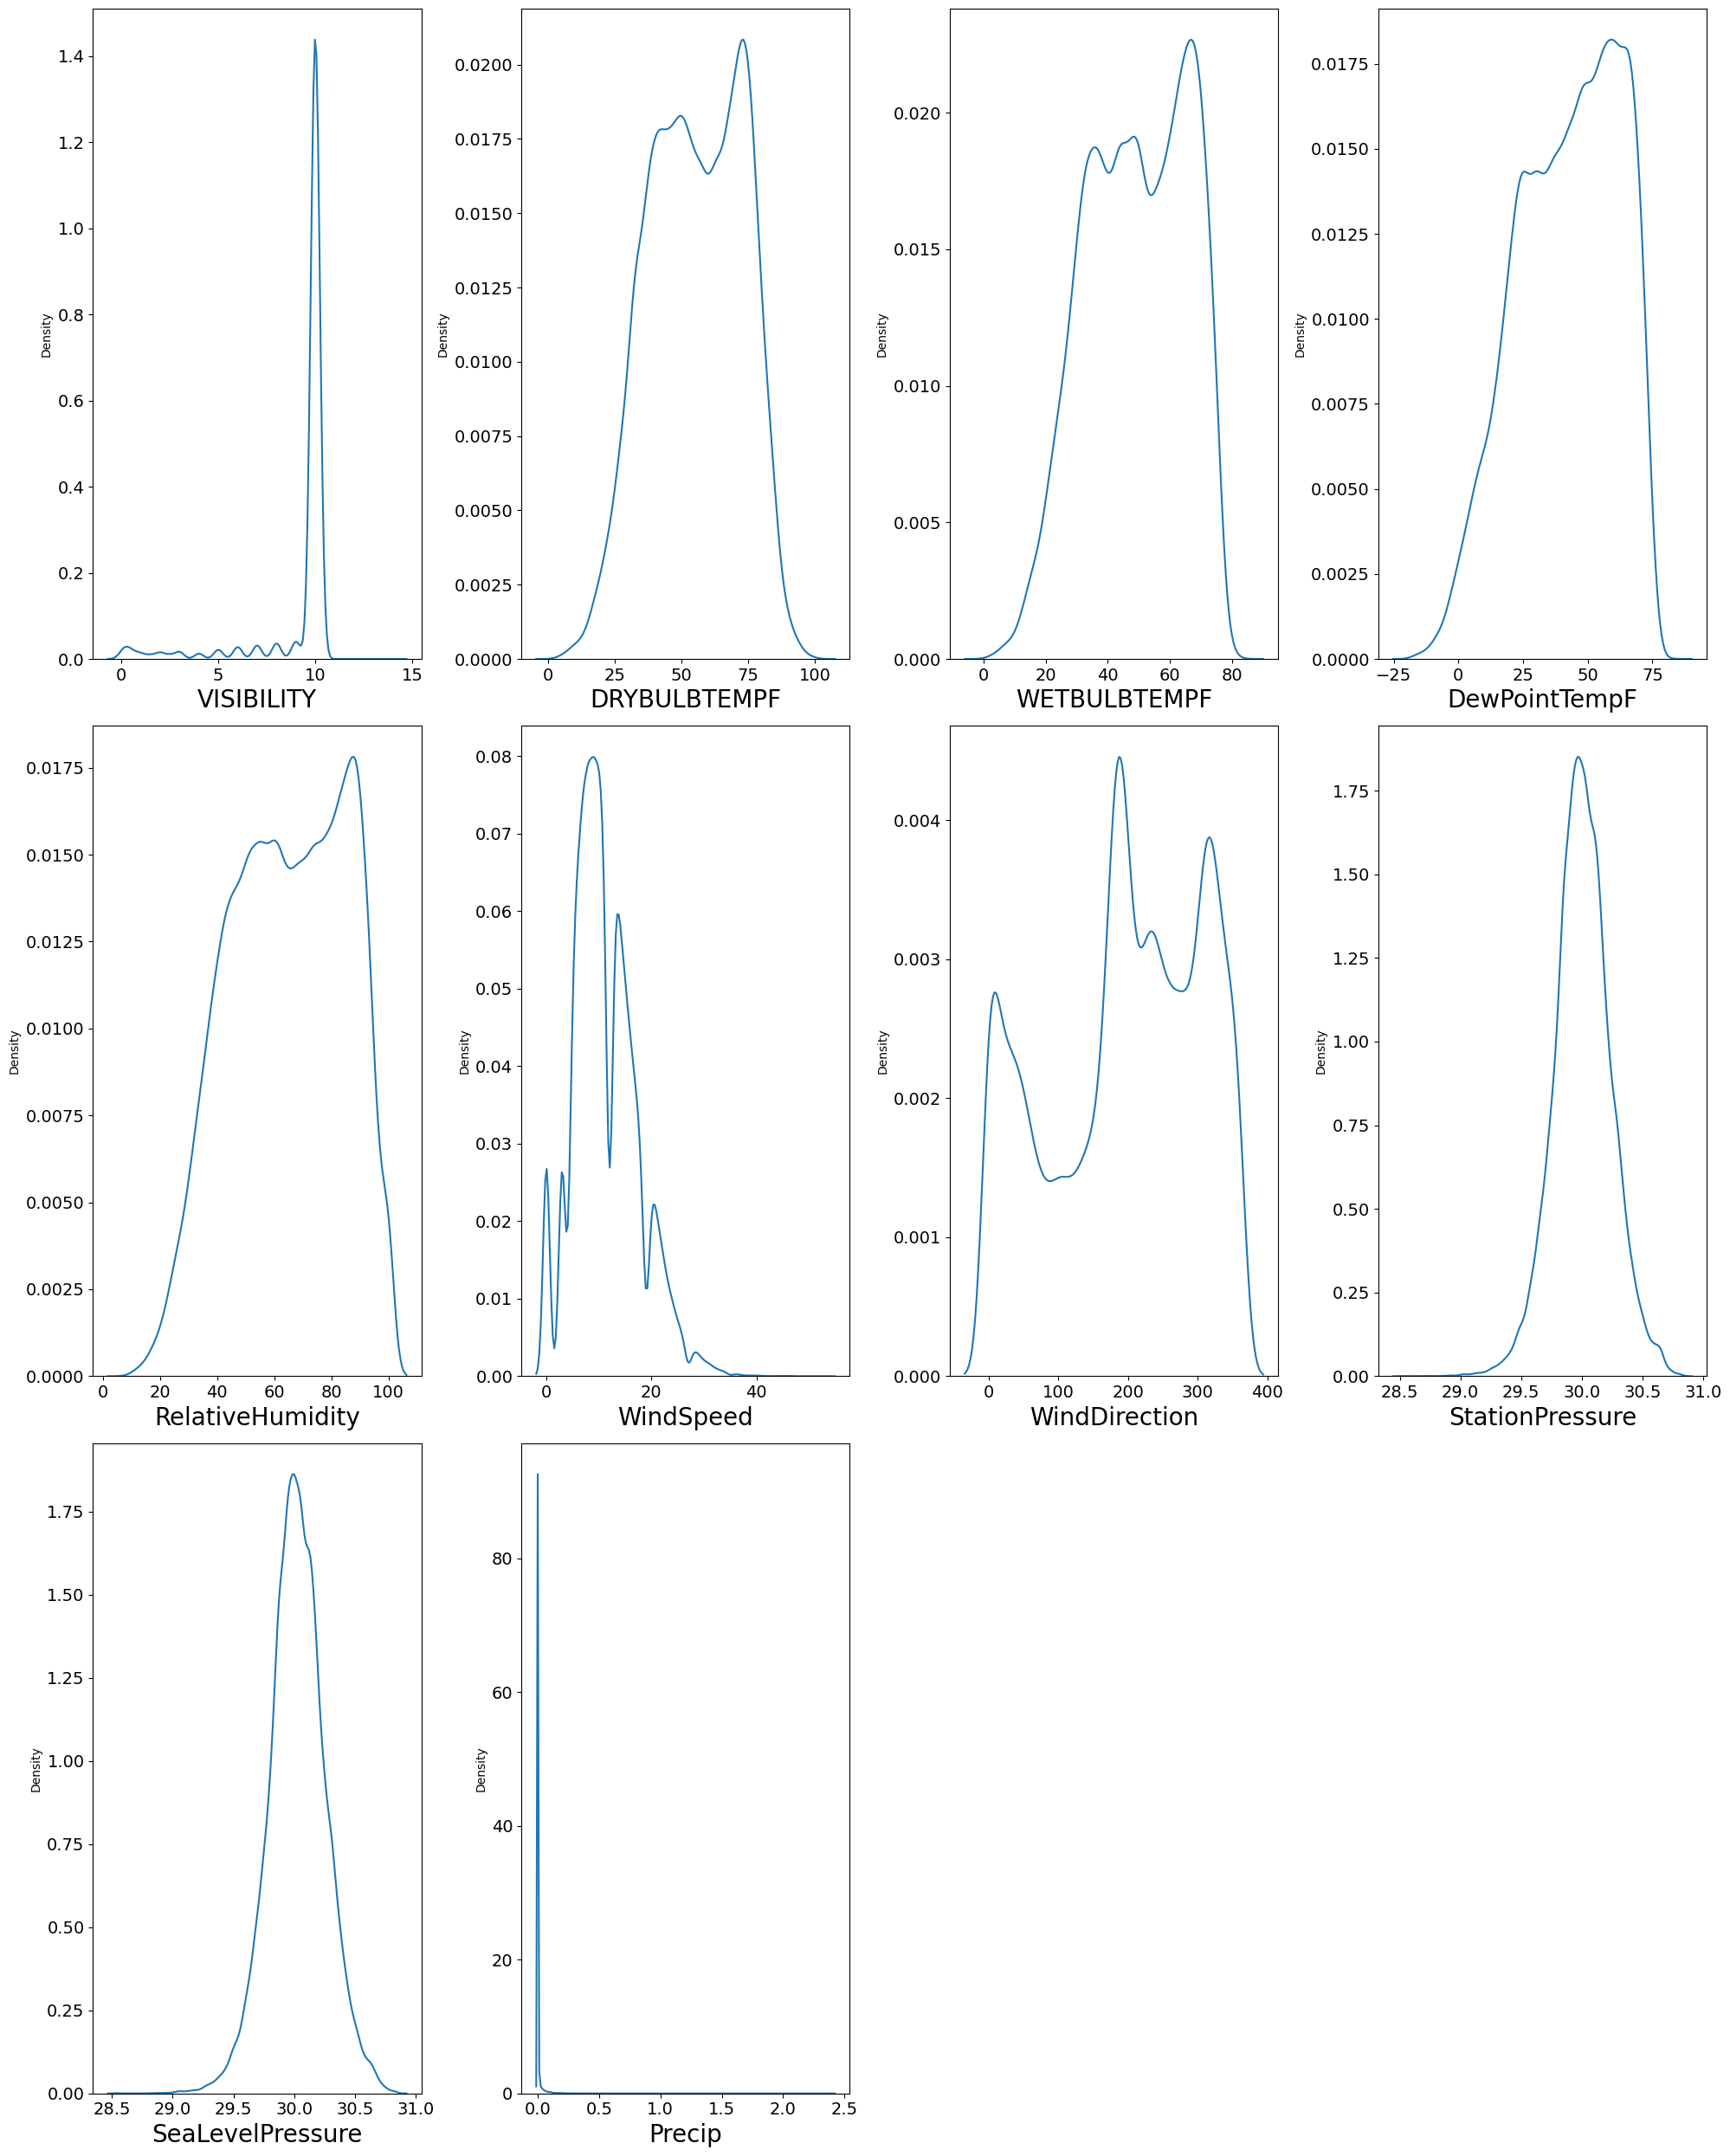

In [13]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber = 1
for column in df.drop(['DATE'],axis=1):
    ax = plt.subplot(3,4,plotnumber)
    sns.kdeplot(df[column])
    plt.xlabel(column,fontsize=20)
    plt.tick_params(axis='both', labelsize=14)
    plotnumber+=1
plt.tight_layout()

In [14]:
#variance of precip columns will be close to zero so we can drop it
df.drop(['Precip'],axis=1,inplace=True)

<Axes: >

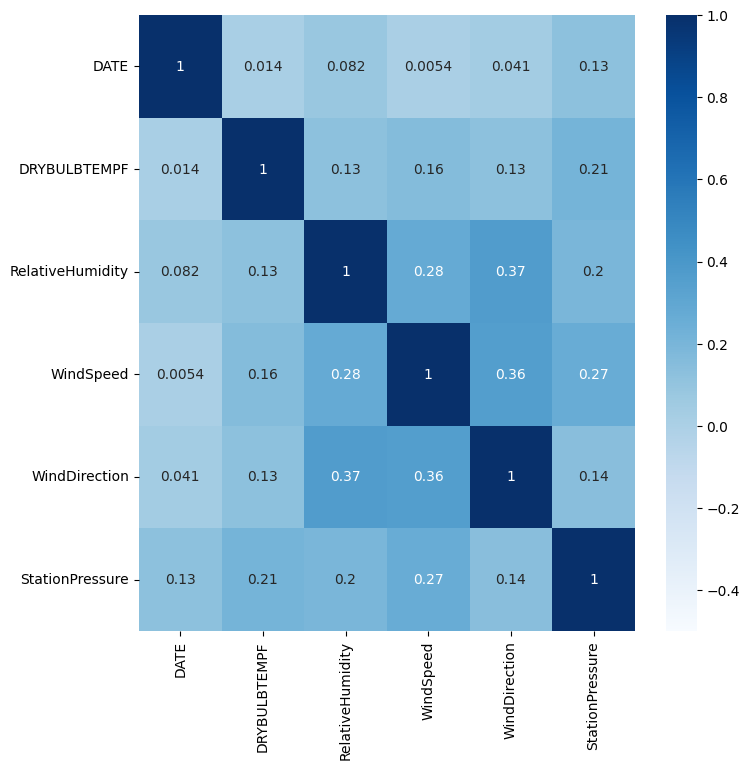

In [32]:
plt.figure(figsize=(8,8))
plt_data = df.drop(columns = ['VISIBILITY'],axis=1)
sns.heatmap(plt_data.corr().abs(),vmin=-0.5,vmax=1,annot=True,cmap='Blues')


In [50]:
#drop columns with high correlation

In [26]:
df.drop(['WETBULBTEMPF','DewPointTempF','SeaLevelPressure'],axis=1,inplace=True)

<Axes: >

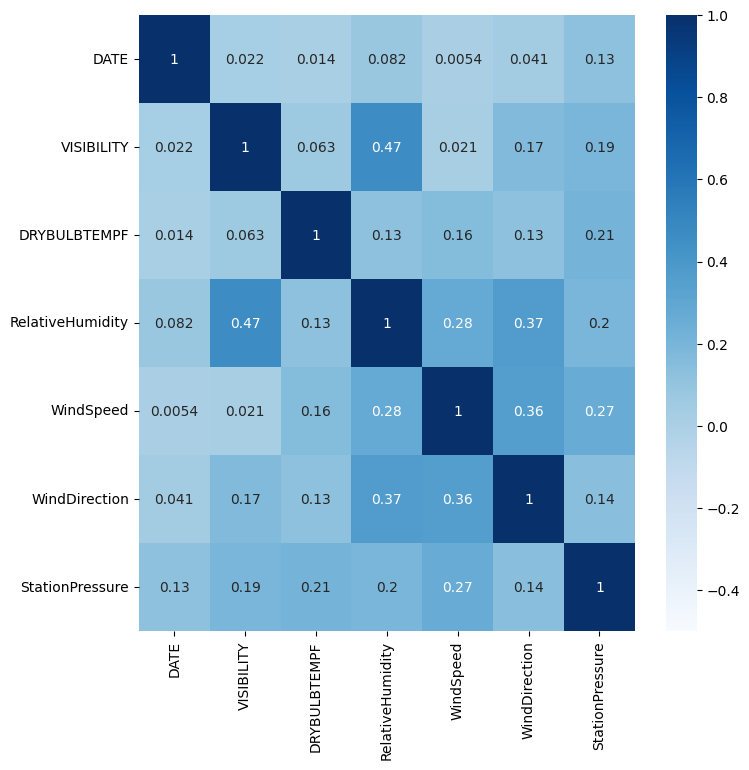

In [33]:
plt.figure(figsize=(8,8))
plt_data = df
sns.heatmap(plt_data.corr().abs(),vmin=-0.5,vmax=1,annot=True,cmap='Blues')